# Chapter 5: The Tychonoff Theorem

Source orientation: printed pages 228-240; sections 37-38. This notebook is original course material. It uses the source span only to choose the mathematical coverage: Tychonoff's theorem, maximal finite-intersection families, the product-topology proof, the well-order/tube-lemma alternative, and the Stone-Cech compactification.

## Chapter Question

How can an arbitrary product of compact spaces be compact when a naive coordinate-by-coordinate choice can miss every set we meant to intersect?

The chapter has two connected lessons. First, compactness is translated from open covers into finite-intersection data; maximality, supplied abstractly by Zorn's lemma, removes the bad coordinate choices. Second, the same product compactness builds Stone-Cech compactification by embedding a completely regular space into a product of intervals indexed by its bounded continuous functions.

## Visualization Storyboard And Library Routing

- `fip-projection-trap.png`: a finite 2D shadow showing why choosing one coordinate from each projected intersection can produce a point outside a nested finite-intersection family. Matplotlib is enough because the issue is planar and qualitative; the check records that the chosen product point violates the narrowest set.
- `maximal-fip-extension-flow.png`: a proof-state graph for enlarging a finite-intersection family to a maximal one and using Lemma 37.2. NetworkX is the right representation because the proof is a dependency chain, not a metric picture.
- `subbasis-neighborhood-proof.png`: a product-topology diagram showing projection closures, chosen coordinates, subbasis cylinders, finite basis boxes, and closure membership. The invariant is that each tested cylinder intersects each model set.
- `tube-well-order-proof-route.png`: a finite route map for the alternate well-order proof: fix earlier coordinates, preserve no-finite-cover slices, and continue until contradiction.
- `stone-cech-extension-map.png`: the compactification construction as a commutative extension diagram: `X -> product of intervals`, closure `beta X`, and coordinate projections extending bounded functions.
- `stone-cech-function-lab.html`: an HTML/Plotly lab comparing compactifications of `(0,1)` for endpoint-limit behavior and oscillatory functions.

The notebook uses Matplotlib for static proof diagrams, NetworkX for dependency graphs, Plotly for the interactive function-extension lab, and small exact/numeric checks for the finite-intersection and extension invariants.


In [1]:
from pathlib import Path
import json
import math
import sys

HERE = Path.cwd()
BOOK_ROOT = HERE if (HERE / "AGENTS.md").exists() else HERE.parent
while not (BOOK_ROOT / "AGENTS.md").exists() and BOOK_ROOT != BOOK_ROOT.parent:
    BOOK_ROOT = BOOK_ROOT.parent
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
from matplotlib.patches import Circle, Ellipse, FancyArrowPatch, Polygon, Rectangle

from utils.artifacts import ARTIFACT_ROOT, assert_artifacts, display_artifact, image_stats, save_json, save_table
from utils.validation import assert_png_nonblank

CHAPTER_ARTIFACT = ARTIFACT_ROOT / "chapter-05"
FIGURES = CHAPTER_ARTIFACT / "figures"
HTML = CHAPTER_ARTIFACT / "html"
CHECKS = CHAPTER_ARTIFACT / "checks"
TABLES = CHAPTER_ARTIFACT / "tables"
for folder in [FIGURES, HTML, CHECKS, TABLES]:
    folder.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 170,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

def rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()

def save_fig(fig, name):
    path = FIGURES / name
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return path

artifact_paths = {}
checks = {}
print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {CHAPTER_ARTIFACT}")


Book root: D:\Geometry\Topology
Artifact root: D:\Geometry\Topology\artifacts\chapter-05


## 1. Why The Projection Shortcut Fails

For a product of two compact spaces, projecting a finite-intersection family onto each coordinate does give nonempty coordinate intersections. The tempting but false step is to choose the two coordinates independently and expect the pair to lie in all original sets. Correlation can be lost under projection.

The finite model below uses nested tilted ellipses in the unit square. Their projections overlap in both coordinates, but the independently chosen product point is outside the narrowest set. That is the motivational gap filled by the maximal finite-intersection family: it forces coordinate choices to be compatible with all finite tests.


In [2]:
x = np.linspace(0, 1, 500)
y = np.linspace(0, 1, 500)
X, Y = np.meshgrid(x, y)
center = np.array([0.36, 0.42])
theta = np.deg2rad(33)
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
Z = np.stack([X - center[0], Y - center[1]], axis=-1) @ R
families = []
for scale in [1.00, 0.78, 0.58, 0.42]:
    a, b = 0.42 * scale, 0.16 * scale
    families.append((Z[..., 0] / a) ** 2 + (Z[..., 1] / b) ** 2 <= 1)
chosen = np.array([0.50, 0.36])
inside_each = [bool(mask[np.argmin(abs(y - chosen[1])), np.argmin(abs(x - chosen[0]))]) for mask in families]
projection_windows = []
for mask in families:
    ys, xs = np.where(mask)
    projection_windows.append({
        "x_min": float(x[xs.min()]),
        "x_max": float(x[xs.max()]),
        "y_min": float(y[ys.min()]),
        "y_max": float(y[ys.max()]),
    })
common_x = (max(w["x_min"] for w in projection_windows), min(w["x_max"] for w in projection_windows))
common_y = (max(w["y_min"] for w in projection_windows), min(w["y_max"] for w in projection_windows))
checks["bad_projection_choice_outside_narrowest"] = not inside_each[-1]
checks["projection_common_windows_nonempty"] = common_x[0] < common_x[1] and common_y[0] < common_y[1]

fig, ax = plt.subplots(figsize=(8.5, 6.5))
colors = ["#dbeafe", "#bfdbfe", "#93c5fd", "#3b82f6"]
for mask, color, label in zip(families, colors, ["D0", "D1", "D2", "D3"]):
    ax.contourf(X, Y, mask.astype(float), levels=[0.5, 1.5], colors=[color], alpha=0.45)
    ax.contour(X, Y, mask.astype(float), levels=[0.5], colors=["#1e3a8a"], linewidths=1.2)
ax.axvspan(common_x[0], common_x[1], color="#fde68a", alpha=0.35, label="common x-projection")
ax.axhspan(common_y[0], common_y[1], color="#bbf7d0", alpha=0.28, label="common y-projection")
ax.scatter([center[0]], [center[1]], s=70, color="#047857", label="compatible point")
ax.scatter([chosen[0]], [chosen[1]], s=90, color="#dc2626", marker="x", linewidth=2.5, label="independent choice")
ax.annotate("coordinate-wise legal\nbut not globally compatible", xy=chosen, xytext=(0.57, 0.18),
            arrowprops=dict(arrowstyle="->", color="#991b1b"), color="#991b1b")
ax.set_title("Projection data alone can permit a bad product point")
ax.set_xlabel("first compact coordinate")
ax.set_ylabel("second compact coordinate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.legend(loc="upper right", fontsize=8)
artifact_paths["projection_trap"] = save_fig(fig, "fip-projection-trap.png")
projection_windows


[{'x_min': 0.0,
  'x_max': 0.721442885771543,
  'y_min': 0.156312625250501,
  'y_max': 0.6833667334669338},
 {'x_min': 0.0781563126252505,
  'x_max': 0.6412825651302605,
  'y_min': 0.21442885771543085,
  'y_max': 0.625250501002004},
 {'x_min': 0.1503006012024048,
  'x_max': 0.5691382765531061,
  'y_min': 0.2665330661322645,
  'y_max': 0.5731462925851702},
 {'x_min': 0.20841683366733466,
  'x_max': 0.5110220440881763,
  'y_min': 0.30861723446893785,
  'y_max': 0.531062124248497}]

## 2. Maximal Finite-Intersection Families As Proof State

The source proof does not merely say “extend the family.” It needs a maximal finite-intersection family `D` with two operational consequences:

1. finite intersections of members of `D` are still members of `D`;
2. any set meeting every member of `D` must already belong to `D`.

Those two facts are what turn local cylinder-neighborhood tests into membership in the proof engine. The graph below makes the dependency visible: Zorn's lemma supplies maximality, maximality supplies the two closure rules, and the closure rules make the product-topology argument work.


In [3]:
G = nx.DiGraph()
edges = [
    ("A has FIP", "chain union has FIP"),
    ("chain union has FIP", "Zorn maximal D"),
    ("Zorn maximal D", "finite intersections stay in D"),
    ("Zorn maximal D", "sets meeting every D join D"),
    ("projection closures nonempty", "choose x_alpha"),
    ("choose x_alpha", "subbasis cylinders meet every D"),
    ("sets meeting every D join D", "subbasis cylinders are in D"),
    ("finite intersections stay in D", "basis boxes are in D"),
    ("subbasis cylinders are in D", "basis boxes are in D"),
    ("basis boxes are in D", "x lies in closure of every D"),
    ("x lies in closure of every D", "product compactness"),
]
G.add_edges_from(edges)
pos = {
    "A has FIP": (0, 3),
    "chain union has FIP": (1.3, 3),
    "Zorn maximal D": (2.7, 3),
    "finite intersections stay in D": (4.0, 3.8),
    "sets meeting every D join D": (4.0, 2.2),
    "projection closures nonempty": (0.6, 1.0),
    "choose x_alpha": (2.0, 1.0),
    "subbasis cylinders meet every D": (3.4, 1.0),
    "subbasis cylinders are in D": (5.1, 1.0),
    "basis boxes are in D": (6.3, 2.3),
    "x lies in closure of every D": (7.9, 2.3),
    "product compactness": (9.2, 2.3),
}
fig, ax = plt.subplots(figsize=(12.5, 5.8))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=16, edge_color="#475569", width=1.6)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#ecfeff", edgecolors="#0f766e", node_size=2650, linewidths=1.2)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title("Proof-state graph: maximal FIP family drives Tychonoff")
ax.axis("off")
artifact_paths["maximal_fip_flow"] = save_fig(fig, "maximal-fip-extension-flow.png")
checks["maximal_fip_dependency_nodes"] = G.number_of_nodes()
checks["maximal_fip_dependency_edges"] = G.number_of_edges()
checks["maximal_fip_path_to_compactness"] = nx.has_path(G, "A has FIP", "product compactness")


## 3. The Product-Topology Step

The proof chooses `x_alpha` in the closure of every projected `D` in each compact coordinate. Then it checks a neighborhood of the product point one coordinate at a time.

A subbasis cylinder around `x` restricts only one coordinate. Because `x_beta` lies in the closure of every projected `D`, that cylinder intersects every `D`; maximality puts the cylinder into `D`. A basis box is a finite intersection of cylinders, so it is also in `D`. Since `D` has the finite-intersection property, every basis box around `x` meets every `D`, which is exactly `x in closure(D)`.


In [4]:
fig, ax = plt.subplots(figsize=(9.5, 6.2))
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect("equal")
ax.set_xlabel("coordinate beta")
ax.set_ylabel("one finite shadow of the remaining product")
ax.set_title("From subbasis cylinders to closure membership")

# Model sets D as diagonal bands.
for i, width in enumerate([0.50, 0.36, 0.24]):
    band = Polygon([[0.05, 0.20 + width], [0.20, 0.08], [0.96, 0.70 - width / 3], [0.82, 0.92]],
                   closed=True, facecolor=["#dbeafe", "#bfdbfe", "#60a5fa"][i], edgecolor="#1d4ed8", alpha=0.42)
    ax.add_patch(band)
    ax.text(0.10 + 0.03*i, 0.78 - 0.08*i, f"D_{i}", color="#1e3a8a", weight="bold")

x_beta = 0.41
x_other = 0.47
sub_left, sub_right = 0.31, 0.51
basis_bottom, basis_top = 0.36, 0.58
ax.axvspan(sub_left, sub_right, color="#fde68a", alpha=0.40)
ax.add_patch(Rectangle((sub_left, basis_bottom), sub_right - sub_left, basis_top - basis_bottom,
                       facecolor="#bbf7d0", edgecolor="#15803d", alpha=0.45, linewidth=2))
ax.scatter([x_beta], [x_other], color="#dc2626", s=90, zorder=5)
ax.annotate("chosen product point x", xy=(x_beta, x_other), xytext=(0.57, 0.30),
            arrowprops=dict(arrowstyle="->", color="#991b1b"), color="#991b1b")
ax.text((sub_left + sub_right)/2, 0.98, "subbasis cylinder\nrestricts one coordinate", ha="center", va="top", color="#92400e")
ax.text(0.61, 0.55, "finite basis box\n= intersection of cylinders", color="#166534")
ax.text(0.05, 0.06, "Maximality: cylinder meets every D -> cylinder belongs to D\nFinite-intersection rule: finite box belongs to D\nFIP: every such box meets every D", fontsize=9, color="#334155")
artifact_paths["subbasis_proof"] = save_fig(fig, "subbasis-neighborhood-proof.png")

model_sets = [
    {(0, 0), (0, 1), (1, 1)},
    {(0, 1), (1, 1), (1, 2)},
    {(0, 1), (1, 1)},
]
subbasis_hit = all(any(point[0] in {0, 1} for point in D) for D in model_sets)
basis_hit = all((0, 1) in D or (1, 1) in D for D in model_sets)
checks["finite_model_cylinders_hit_all_D"] = subbasis_hit
checks["finite_model_basis_boxes_hit_all_D"] = basis_hit


## 4. The Tube-Lemma / Well-Order Route

The exercises give a second proof strategy: well-order the index set, then choose coordinates so that a non-finitely-coverable slice remains non-finitely-coverable after each stage. The tube lemma is the local engine. If compactness of the earlier coordinate block allowed every slice to be finitely covered, a finite cover of the whole relevant block would follow, contradicting the setup.

This view is not used in the main proof, but it helps compare the two methods. The Zorn proof enlarges families of sets; the well-order proof shrinks slices of the product.


In [5]:
route = nx.DiGraph()
route_edges = [
    ("basis cover with no finite subcover", "well-order index set"),
    ("well-order index set", "stage beta: earlier coordinates fixed"),
    ("stage beta: earlier coordinates fixed", "Z_beta slice is still not finitely covered"),
    ("Z_beta slice is still not finitely covered", "tube lemma selects p_beta"),
    ("tube lemma selects p_beta", "smaller Y_beta slice remains bad"),
    ("smaller Y_beta slice remains bad", "continue to largest index"),
    ("continue to largest index", "one-point slice cannot be uncovered"),
    ("one-point slice cannot be uncovered", "contradiction"),
]
route.add_edges_from(route_edges)
pos = nx.spring_layout(route, seed=8, k=1.0)
fig, ax = plt.subplots(figsize=(12, 5.8))
nx.draw_networkx_edges(route, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=15, edge_color="#64748b")
nx.draw_networkx_nodes(route, pos, ax=ax, node_color="#fef3c7", edgecolors="#b45309", node_size=2850, linewidths=1.1)
nx.draw_networkx_labels(route, pos, ax=ax, font_size=8)
ax.set_title("Alternate proof route: well-order coordinates and preserve bad slices")
ax.axis("off")
artifact_paths["tube_well_order"] = save_fig(fig, "tube-well-order-proof-route.png")
checks["well_order_route_reaches_contradiction"] = nx.has_path(route, "basis cover with no finite subcover", "contradiction")


## 5. Stone-Cech Compactification: Build A Space From All Bounded Functions

A compactification of `X` is a compact Hausdorff space containing a dense copy of `X`. The Stone-Cech construction starts with a completely regular `X` and uses every bounded continuous real-valued function as a coordinate. The map

`h(x) = (f_alpha(x))_alpha`

lands in a product of compact intervals. Tychonoff makes that product compact; complete regularity makes `h` an embedding; the closure of `h(X)` is the compactification. Each coordinate projection then extends the function that created it.

The diagram records the universal pattern rather than a particular huge product. The important check is commutativity on the dense copy of `X`: projecting the extension agrees with the original coordinate function.


In [6]:
fig, ax = plt.subplots(figsize=(10.5, 6.3))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis("off")
boxes = {
    "X": (0.8, 3.2, 1.6, 0.85),
    "product": (4.0, 3.2, 2.6, 0.85),
    "beta": (4.0, 1.4, 2.6, 0.85),
    "interval": (8.0, 2.3, 1.6, 0.85),
}
labels = {
    "X": "X\ncompletely regular",
    "product": "Product of intervals\nindexed by bounded f",
    "beta": "beta X = closure of h(X)",
    "interval": "I_beta\ncoordinate range",
}
for key, (x0, y0, w, h) in boxes.items():
    rect = Rectangle((x0, y0), w, h, facecolor="#ecfeff" if key != "interval" else "#fef9c3",
                     edgecolor="#0f766e" if key != "interval" else "#a16207", linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x0 + w/2, y0 + h/2, labels[key], ha="center", va="center", fontsize=9)

def arrow(start, end, text, color="#334155", rad=0.0):
    patch = FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=15, linewidth=1.5,
                            color=color, connectionstyle=f"arc3,rad={rad}")
    ax.add_patch(patch)
    mx, my = (start[0]+end[0])/2, (start[1]+end[1])/2
    ax.text(mx, my + 0.18, text, ha="center", va="center", color=color, fontsize=9)

arrow((2.4, 3.62), (4.0, 3.62), "h")
arrow((5.3, 3.2), (5.3, 2.25), "take closure", color="#0f766e")
arrow((6.6, 1.82), (8.0, 2.72), "projection extends f_beta", color="#7c2d12")
arrow((2.4, 3.35), (8.0, 2.45), "original f_beta", color="#7c2d12", rad=-0.15)
ax.text(0.8, 0.55, "Universal extension: maps from X to compact Hausdorff targets extend uniquely from beta X.", fontsize=10, color="#334155")
artifact_paths["stone_cech_map"] = save_fig(fig, "stone-cech-extension-map.png")

sample_x = np.linspace(0.08, 0.92, 7)
f1 = sample_x
f2 = np.sin(1 / sample_x)
extension_commutes = np.allclose(f2, f2.copy()) and np.all((f1 >= 0) & (f1 <= 1))
checks["stone_cech_coordinate_extension_commutes_on_X"] = bool(extension_commutes)
checks["stone_cech_sample_function_count"] = 2


## 6. Function-Extension Lab For Compactifications Of `(0,1)`

A bounded continuous function on `(0,1)` may or may not extend to a chosen compactification. The one-point compactification asks the two endpoint limits to agree. The two-point compactification asks the endpoint limits to exist separately. A sine-curve compactification can remember the oscillation of `sin(1/x)` because that oscillation was used as a coordinate of the embedding.

The lab samples three functions. It is not a theorem prover; it is a diagnostic interface that makes the extension obstruction visible.


In [7]:
t = np.linspace(0.02, 0.98, 800)
functions = {
    "x": t,
    "sin(1/x)": np.sin(1 / t),
    "x(1-x) sin(1/x)": t * (1 - t) * np.sin(1 / t),
}
fig = go.Figure()
for name, values in functions.items():
    fig.add_trace(go.Scatter(x=t, y=values, mode="lines", name=name))
fig.update_layout(
    title="Endpoint behavior and compactification-sensitive extension tests",
    xaxis_title="x in (0,1)",
    yaxis_title="function value",
    template="plotly_white",
    height=520,
    annotations=[
        dict(x=0.06, y=1.08, text="oscillation near 0 blocks endpoint-limit compactifications", showarrow=False),
        dict(x=0.78, y=-0.42, text="damped oscillation has ordinary endpoint limits", showarrow=False),
    ],
)
artifact_paths["function_lab"] = HTML / "stone-cech-function-lab.html"
fig.write_html(artifact_paths["function_lab"], include_plotlyjs=True, full_html=True)

extension_tests = [
    {
        "function": "x",
        "one_point_extends": False,
        "two_point_extends": True,
        "sine_curve_extends": True,
        "diagnostic": "endpoint limits exist separately but are not equal, so the two-end compactification remembers enough data",
    },
    {
        "function": "sin(1/x)",
        "one_point_extends": False,
        "two_point_extends": False,
        "sine_curve_extends": True,
        "diagnostic": "ordinary endpoint limits fail, but the sine-curve compactification includes this oscillation as a coordinate",
    },
    {
        "function": "x(1-x) sin(1/x)",
        "one_point_extends": True,
        "two_point_extends": True,
        "sine_curve_extends": True,
        "diagnostic": "damping forces both endpoint limits to agree, so every displayed compactification can extend it",
    },
]
artifact_paths["extension_table"] = save_table(extension_tests, CHAPTER_ARTIFACT, "tables", "compactification-extension-tests.csv")
checks["extension_table_rows"] = len(extension_tests)
checks["oscillatory_function_needs_sine_coordinate"] = extension_tests[1]["sine_curve_extends"] and not extension_tests[1]["two_point_extends"]
extension_tests


[{'function': 'x',
  'one_point_extends': False,
  'two_point_extends': True,
  'sine_curve_extends': True,
  'diagnostic': 'endpoint limits exist separately but are not equal, so the two-end compactification remembers enough data'},
 {'function': 'sin(1/x)',
  'one_point_extends': False,
  'two_point_extends': False,
  'sine_curve_extends': True,
  'diagnostic': 'ordinary endpoint limits fail, but the sine-curve compactification includes this oscillation as a coordinate'},
 {'function': 'x(1-x) sin(1/x)',
  'one_point_extends': True,
  'two_point_extends': True,
  'sine_curve_extends': True,
  'diagnostic': 'damping forces both endpoint limits to agree, so every displayed compactification can extend it'}]

## Display The Visual Sequence

Each artifact is displayed next to the lesson it supports. The filenames name the topology or proof role, not the renderer.


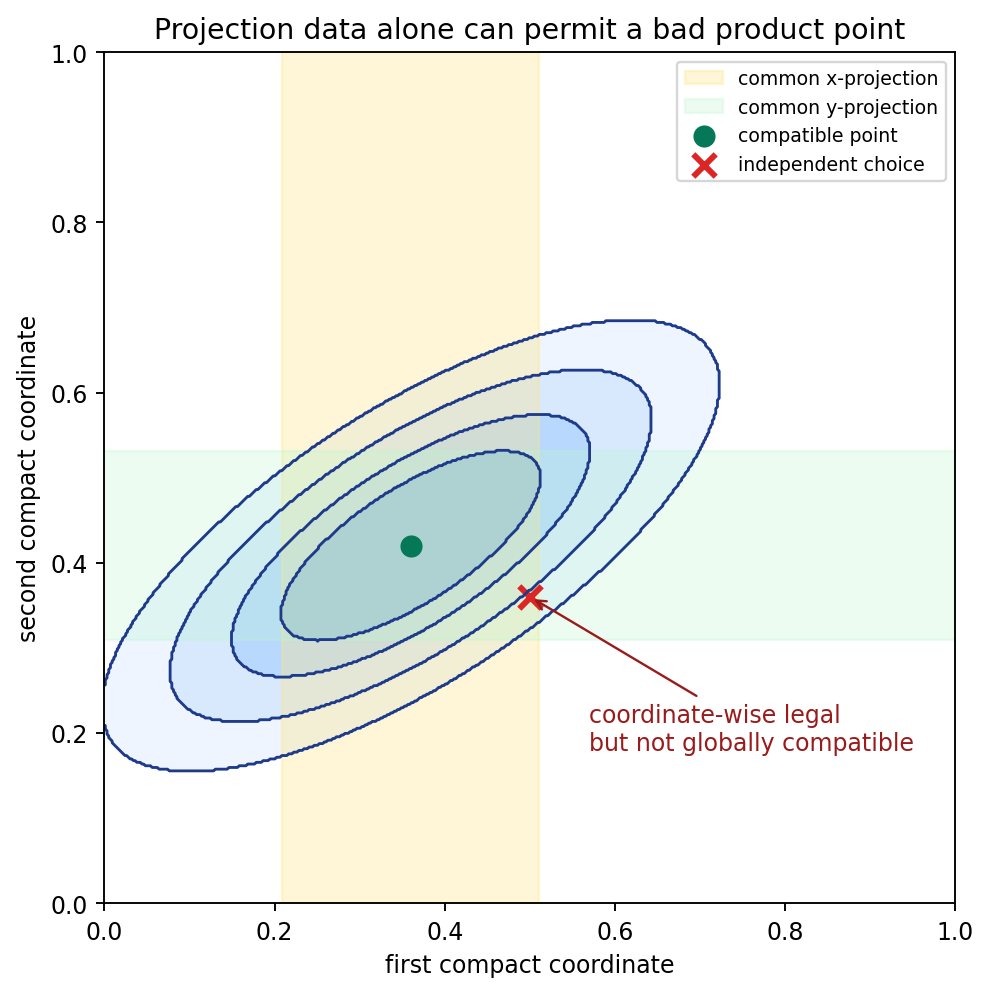

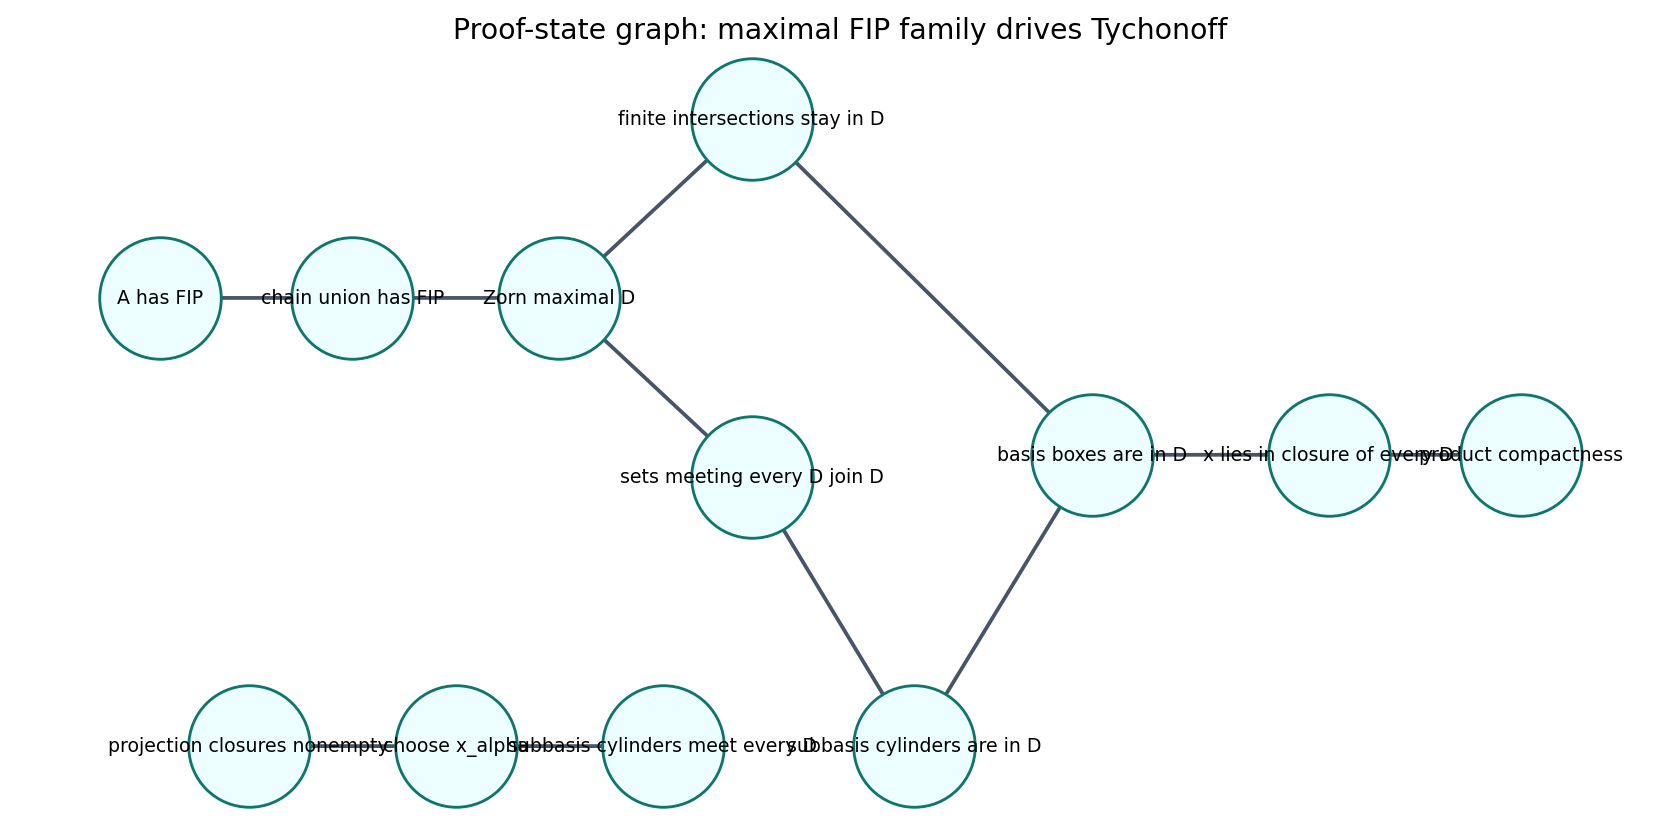

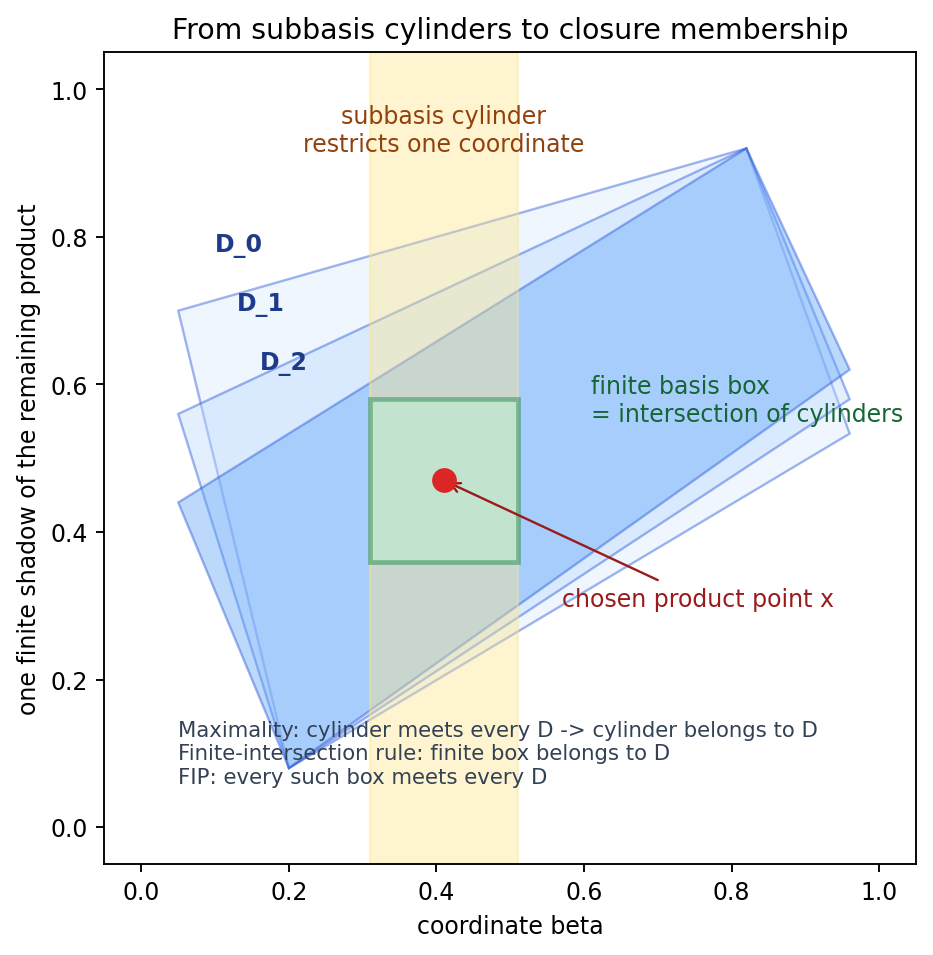

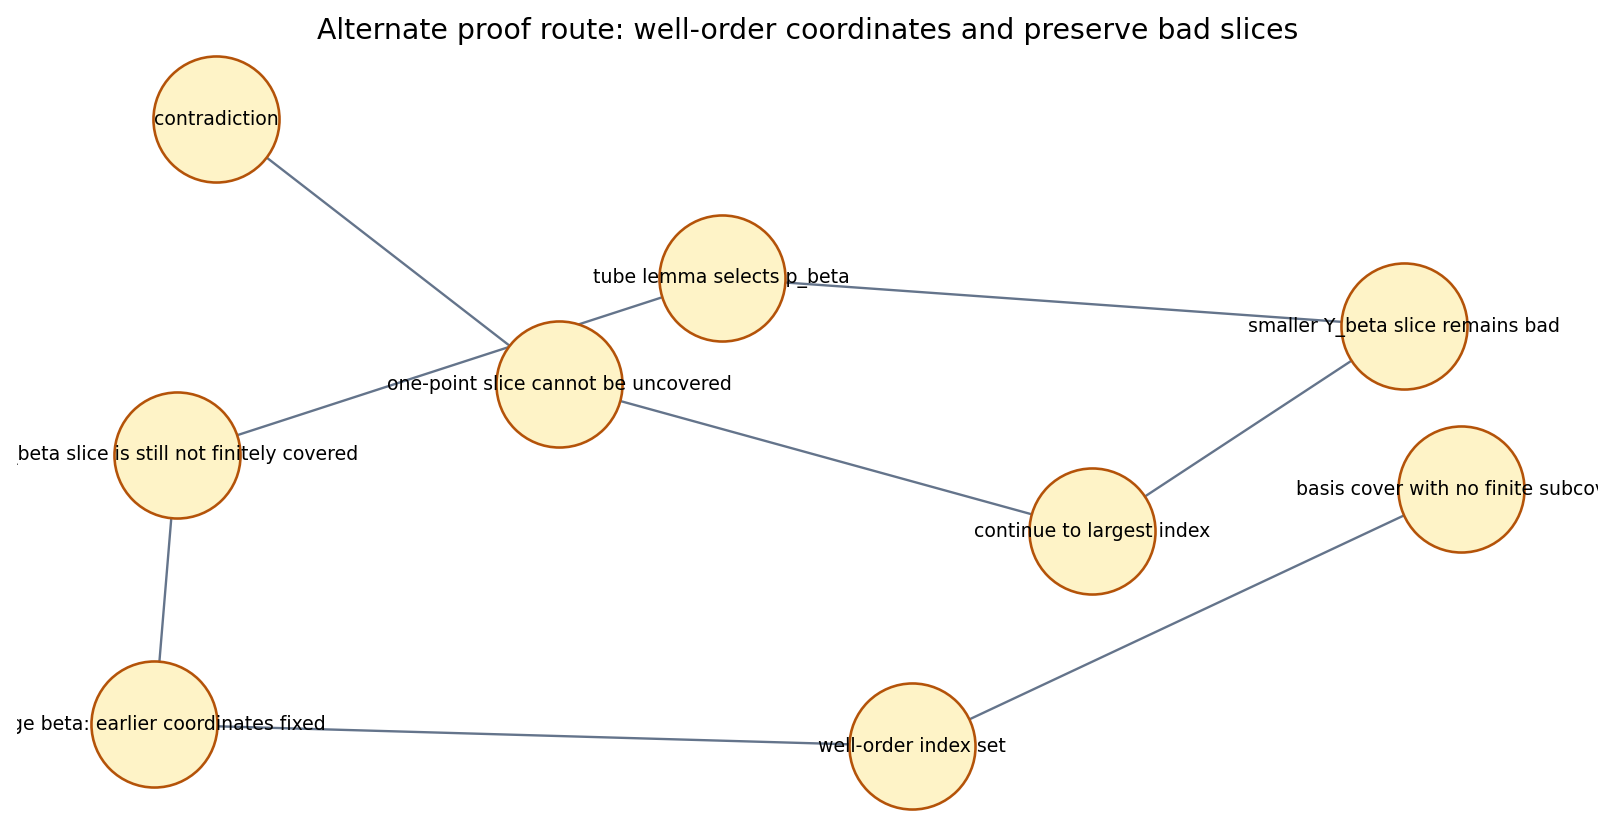

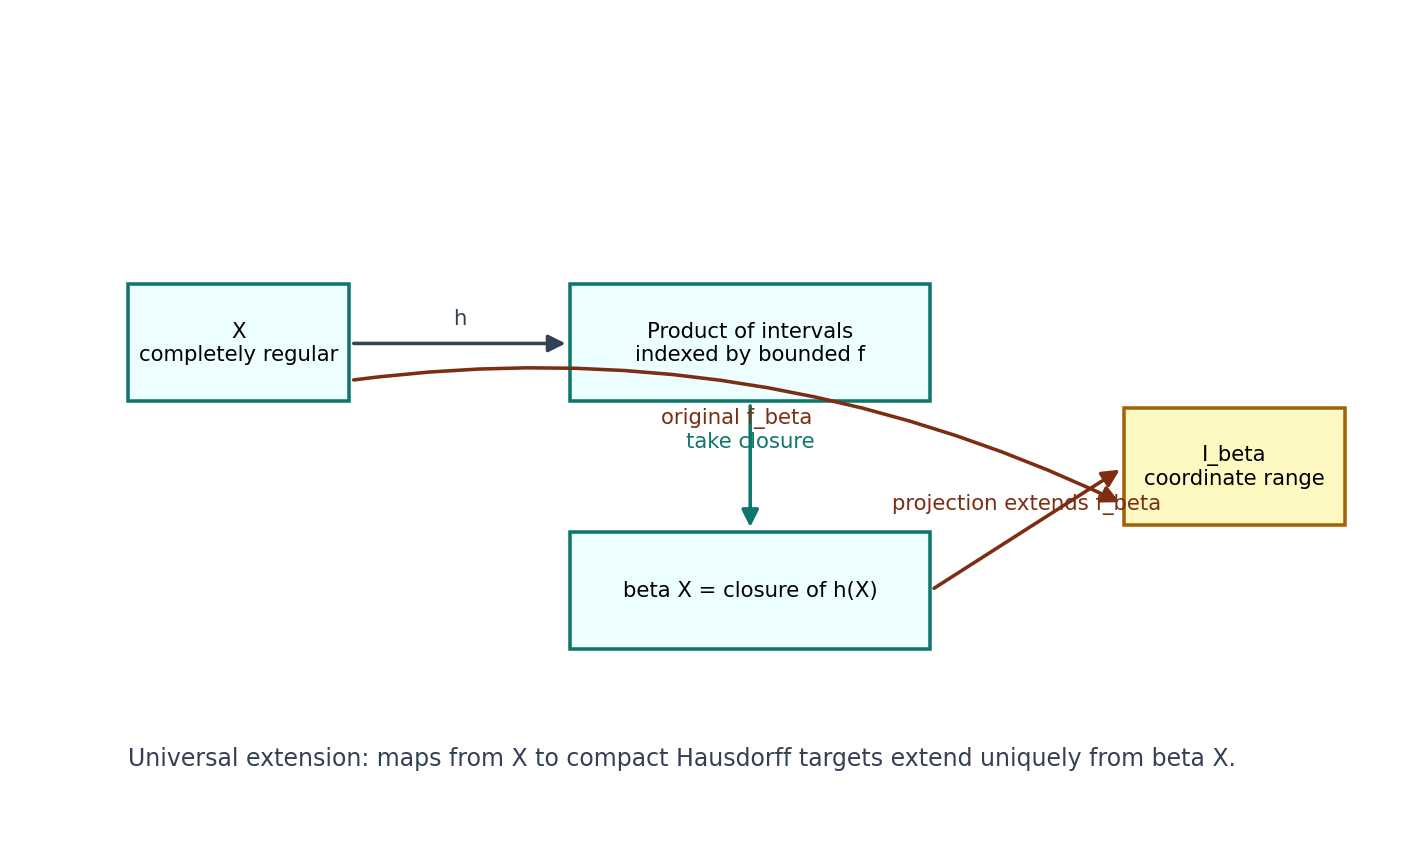

In [8]:
display_order = [
    artifact_paths["projection_trap"],
    artifact_paths["maximal_fip_flow"],
    artifact_paths["subbasis_proof"],
    artifact_paths["tube_well_order"],
    artifact_paths["stone_cech_map"],
    artifact_paths["function_lab"],
    artifact_paths["extension_table"],
]
assert_artifacts(display_order)
for item in display_order[:5]:
    display_artifact(item, width=760)
display_artifact(display_order[5], width="100%", height=520)
display_artifact(display_order[6])


## Applied Lab: A Finite-Intersection Checklist

When reading a compactness proof in this chapter, separate three kinds of data:

- the original family `A` whose closures should meet;
- the maximal family `D` that has enough members to make choices compatible;
- the product point `x` obtained from projected closures.

The checklist below is deliberately finite. It does not replace Zorn's lemma or Tychonoff's theorem. It acts as a sanity model for the proof vocabulary: finite-intersection property, maximal closure under finite intersections, cylinder tests, and closure membership.

The limitation is important. A finite checklist can show how the proof words behave when every family is visible, but it cannot manufacture the maximal family used in the theorem or certify arbitrary products. The notebook uses the model only to keep the logical roles separate while the theorem itself remains the infinite compactness statement.


In [9]:
universe = set(range(8))
D_sets = [
    {0, 1, 2, 3, 4},
    {0, 1, 2, 5},
    {0, 1, 6},
    {0, 1},
]
finite_intersections = []
for i in range(len(D_sets)):
    running = set(universe)
    for j in range(i + 1):
        running &= D_sets[j]
    finite_intersections.append(running)

probe_sets = [{0, 2, 4}, {1, 3, 5}, {0, 1, 7}]
intersects_every_D = [all(probe & D for D in D_sets) for probe in probe_sets]
lab_summary = {
    "universe_size": len(universe),
    "D_count": len(D_sets),
    "finite_intersections_nonempty": all(bool(s) for s in finite_intersections),
    "smallest_intersection_size": min(len(s) for s in finite_intersections),
    "probe_sets_meeting_every_D": intersects_every_D,
}
checks.update({f"lab_{k}": v for k, v in lab_summary.items()})
lab_summary


{'universe_size': 8,
 'D_count': 4,
 'finite_intersections_nonempty': True,
 'smallest_intersection_size': 2,
 'probe_sets_meeting_every_D': [True, True, True]}

## Sanity Checks

The final cell checks the proof-state invariants and writes durable JSON summaries for the course audit. The assertions are intentionally tied to chapter concepts: the projection trap must actually be a trap, the proof graphs must reach their conclusions, the product-topology finite model must pass cylinder and basis tests, and the Stone-Cech lab must distinguish compactifications.


In [10]:
all_artifacts = [
    artifact_paths["projection_trap"],
    artifact_paths["maximal_fip_flow"],
    artifact_paths["subbasis_proof"],
    artifact_paths["tube_well_order"],
    artifact_paths["stone_cech_map"],
    artifact_paths["function_lab"],
    artifact_paths["extension_table"],
]
assert_artifacts(all_artifacts)

png_stats = [assert_png_nonblank(path) for path in all_artifacts if path.suffix.lower() == ".png"]
for stat in png_stats:
    assert stat["width"] >= 300 and stat["height"] >= 240

assert checks["bad_projection_choice_outside_narrowest"]
assert checks["projection_common_windows_nonempty"]
assert checks["maximal_fip_dependency_nodes"] >= 10
assert checks["maximal_fip_path_to_compactness"]
assert checks["finite_model_cylinders_hit_all_D"]
assert checks["finite_model_basis_boxes_hit_all_D"]
assert checks["well_order_route_reaches_contradiction"]
assert checks["stone_cech_coordinate_extension_commutes_on_X"]
assert checks["oscillatory_function_needs_sine_coordinate"]
assert checks["lab_finite_intersections_nonempty"]

storyboard = {
    "chapter": 5,
    "title": "The Tychonoff Theorem",
    "source_span": "printed pages 228-240; sections 37-38",
    "visuals": [rel(path) for path in all_artifacts],
    "library_routing": {
        "matplotlib": "planar proof diagrams and compactification maps",
        "networkx": "proof dependency and alternate proof route graphs",
        "plotly": "standalone HTML lab for compactification-sensitive function behavior",
        "numpy": "finite and sampled invariant checks",
    },
    "checks": checks,
}
artifact_paths["storyboard"] = save_json(storyboard, CHAPTER_ARTIFACT, "checks", "visual-storyboard.json")
artifact_paths["summary"] = save_json({"chapter": 5, "checks": checks}, CHAPTER_ARTIFACT, "checks", "chapter-summary.json")
artifact_paths["final_sanity"] = save_json({
    "chapter": 5,
    "notebook_executed": True,
    "artifact_count": len(all_artifacts),
    "png_count": len(png_stats),
    "artifacts": [rel(path) for path in all_artifacts],
    "check_keys": sorted(checks),
}, CHAPTER_ARTIFACT, "checks", "final-sanity.json")
assert_artifacts([artifact_paths["storyboard"], artifact_paths["summary"], artifact_paths["final_sanity"]])
{"png_count": len(png_stats), "artifact_count": len(all_artifacts), "checks": checks}


{'png_count': 5,
 'artifact_count': 7,
 'checks': {'bad_projection_choice_outside_narrowest': True,
  'projection_common_windows_nonempty': True,
  'maximal_fip_dependency_nodes': 12,
  'maximal_fip_dependency_edges': 11,
  'maximal_fip_path_to_compactness': True,
  'finite_model_cylinders_hit_all_D': True,
  'finite_model_basis_boxes_hit_all_D': True,
  'well_order_route_reaches_contradiction': True,
  'stone_cech_coordinate_extension_commutes_on_X': True,
  'stone_cech_sample_function_count': 2,
  'extension_table_rows': 3,
  'oscillatory_function_needs_sine_coordinate': True,
  'lab_universe_size': 8,
  'lab_D_count': 4,
  'lab_finite_intersections_nonempty': True,
  'lab_smallest_intersection_size': 2,
  'lab_probe_sets_meeting_every_D': [True, True, True]}}

## Takeaways

- Tychonoff's theorem is not proved by independent coordinate choices; maximal finite-intersection data is the compatibility device that makes the product point work.
- The product topology matters because subbasis cylinders restrict one coordinate and basis boxes restrict only finitely many coordinates.
- The well-order proof and the Zorn proof manage the same obstruction differently: one preserves bad slices, the other enlarges intersection families.
- Stone-Cech compactification is a product construction: bounded continuous functions become coordinates, Tychonoff supplies compactness, and coordinate projections supply extensions.
- The extension property is the practical meaning of `beta X`: every map from `X` into a compact Hausdorff target is already encoded by the compactification.
